In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('hotel_booking.csv')

In [3]:
df.sample(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
32930,Resort Hotel,0,0,2017,February,6,9,0,1,2,...,Transient,48.0,0,1,Check-Out,10-02-2017,Timothy Brown,TimothyBrown@zoho.com,528-598-4569,************4187
29140,Resort Hotel,0,7,2016,October,43,17,1,3,2,...,Transient,88.0,1,0,Check-Out,21-10-2016,Kristi Mccann,Kristi_Mccann@zoho.com,866-326-5395,************1022
65330,City Hotel,1,123,2017,March,13,31,1,2,3,...,Transient,158.4,0,1,Canceled,19-12-2016,Paul Clark,Paul_C30@aol.com,995-469-5225,************4963
20572,Resort Hotel,0,2,2016,March,14,30,0,1,1,...,Transient,43.0,0,0,Check-Out,31-03-2016,Sean Jackson,Sean_Jackson@comcast.net,407-444-0512,************8399
19389,Resort Hotel,0,0,2015,December,51,16,0,1,1,...,Transient,35.0,1,0,Check-Out,17-12-2015,Danielle Young,Danielle_Young@mail.com,513-513-1416,************2284


In [4]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'],format = "%d-%m-%Y")

In [7]:
df.shape

(119390, 36)

In [8]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
df.drop(columns = ['company',"agent"],inplace = True)

In [10]:
df.shape

(119390, 34)

In [11]:
df['country'].mode()[0]

'PRT'

In [12]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

In [14]:
df['children'].value_counts()

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

In [15]:
df['children'] = df['children'].fillna(df['children'].mode()[0])

In [16]:
df['children'] = df['children'].apply(lambda x : 1 if x == 10 else x)

In [17]:
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [18]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103811,0.007949,0.031912,0.087118,0.137097,0.221124,2.321149,101.831122,0.062518,0.571363,2016-07-30 00:24:47.883407104
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000,2016-02-01 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000,0.000000,2016-08-07 00:00:00
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-08 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,3.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.397533,0.097436,0.175767,0.844336,1.497437,0.652306,17.594721,50.535790,0.245291,0.792798,NaN


# "Monthly Guest Count: Tracking the Number of Guests Each Month"

In [19]:
df['month_number'] = pd.to_datetime(df['arrival_date_month'],format = '%B').dt.month

In [20]:
booked_city_hotel = df.loc[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 0)]

In [21]:
booked_resort_hotel = df.loc[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 0)]

In [22]:
city_hotel_booking = booked_city_hotel.groupby(['arrival_date_month','month_number'],as_index=False)[['lead_time']].count().rename(columns = {'lead_time':'total_booking','arrival_date_month':'month_name'})

In [23]:
city_hotel_booking.sort_values(['month_number'],inplace = True)

In [24]:
city_hotel_booking.reset_index(drop = True,inplace = True)

In [25]:
city_hotel_booking

,month_name,month_number,total_booking
0,January,1,2254
1,February,2,3064
2,March,3,4072
3,April,4,4015
4,May,5,4579
5,June,6,4366
6,July,7,4782
7,August,8,5381
8,September,9,4290
9,October,10,4337


In [26]:
resort_hotel_booking = booked_resort_hotel.groupby(['arrival_date_month','month_number'],as_index=False)[['lead_time']].count().rename(columns = {'lead_time':'total_booking','arrival_date_month':'month_name'})

In [27]:
resort_hotel_booking.sort_values(['month_number'],inplace = True)

In [28]:
resort_hotel_booking.reset_index(drop = True,inplace = True)

In [29]:
resort_hotel_booking

,month_name,month_number,total_booking
0,January,1,1868
1,February,2,2308
2,March,3,2573
3,April,4,2550
4,May,5,2535
5,June,6,2038
6,July,7,3137
7,August,8,3257
8,September,9,2102
9,October,10,2577


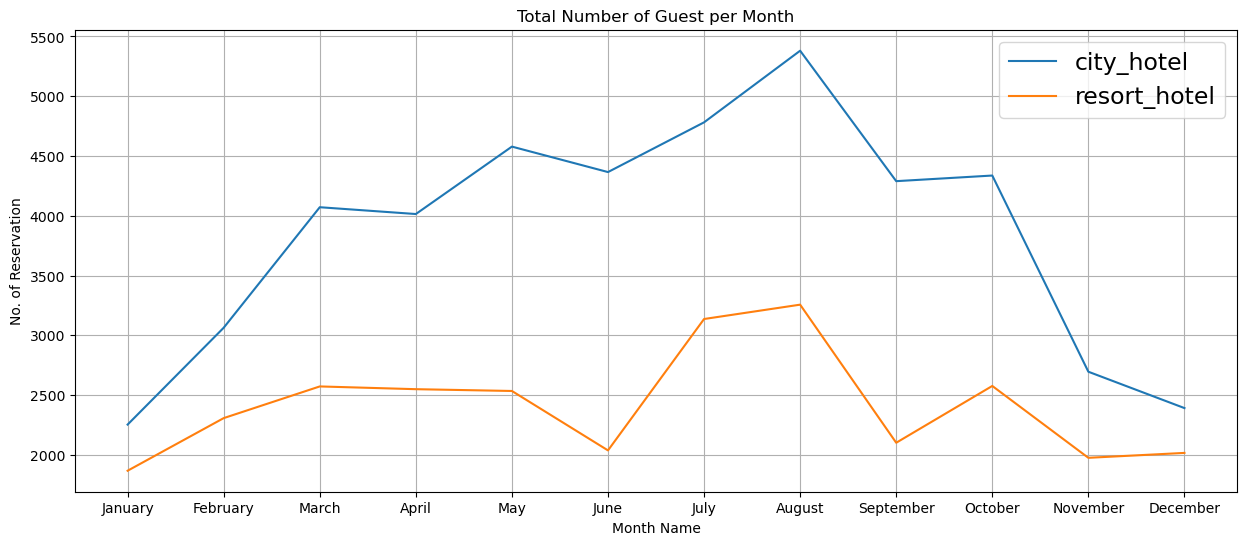

In [30]:
plt.figure(figsize = (15,6))
plt.plot(city_hotel_booking['month_name'],city_hotel_booking['total_booking'],label = 'city_hotel')
plt.plot(resort_hotel_booking['month_name'],resort_hotel_booking['total_booking'],label = 'resort_hotel')
plt.title('Total Number of Guest per Month')
plt.legend(fontsize = 17)
plt.xlabel('Month Name')
plt.ylabel('No. of Reservation')
plt.grid()
plt.show()

In [31]:
cancel_city_hotel = df.loc[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 1)]

In [32]:
cancel_city_hotel_booking = cancel_city_hotel.groupby(['arrival_date_month','month_number'],as_index=False)[['lead_time']].count().rename(columns = {'lead_time':'total_cancel_booking','arrival_date_month':'month_name'})

In [33]:
cancel_city_hotel_booking.sort_values(['month_number'],inplace = True)

In [34]:
cancel_city_hotel_booking.reset_index(drop = True,inplace = True)

In [35]:
cancel_city_hotel_booking

,month_name,month_number,total_cancel_booking
0,January,1,1482
1,February,2,1901
2,March,3,2386
3,April,4,3465
4,May,5,3653
5,June,6,3528
6,July,7,3306
7,August,8,3602
8,September,9,3110
9,October,10,3268


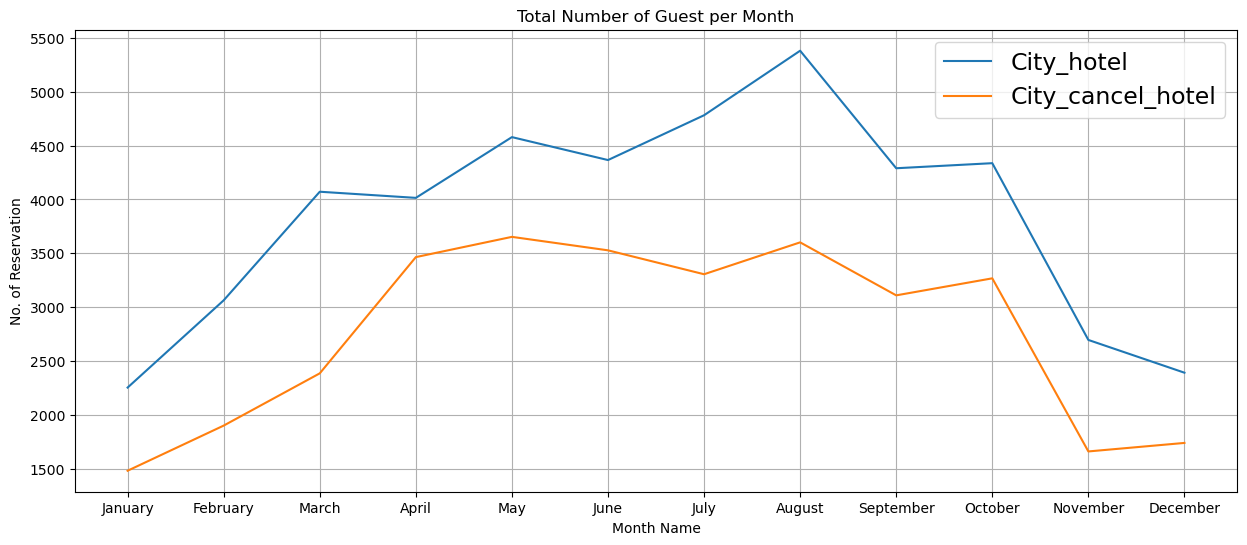

In [36]:
plt.figure(figsize = (15,6))
plt.plot(city_hotel_booking['month_name'],city_hotel_booking['total_booking'],label = 'City_hotel')
plt.plot(cancel_city_hotel_booking['month_name'],cancel_city_hotel_booking['total_cancel_booking'],label = 'City_cancel_hotel')
plt.title('Total Number of Guest per Month')
plt.legend(fontsize = 17)
plt.xlabel('Month Name')
plt.ylabel('No. of Reservation')
plt.grid()
plt.show()

In [37]:
cancel_resort_hotel = df.loc[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 1)]

In [38]:
cancel_resort_hotel_booking = cancel_resort_hotel.groupby(['arrival_date_month','month_number'],as_index=False)[['lead_time']].count().rename(columns = {'lead_time':'total_cancel_booking','arrival_date_month':'month_name'})

In [39]:
cancel_resort_hotel_booking.sort_values(['month_number'],inplace = True)

In [40]:
cancel_resort_hotel_booking.reset_index(drop = True,inplace = True)

In [41]:
cancel_resort_hotel_booking

,month_name,month_number,total_cancel_booking
0,January,1,325
1,February,2,795
2,March,3,763
3,April,4,1059
4,May,5,1024
5,June,6,1007
6,July,7,1436
7,August,8,1637
8,September,9,1006
9,October,10,978


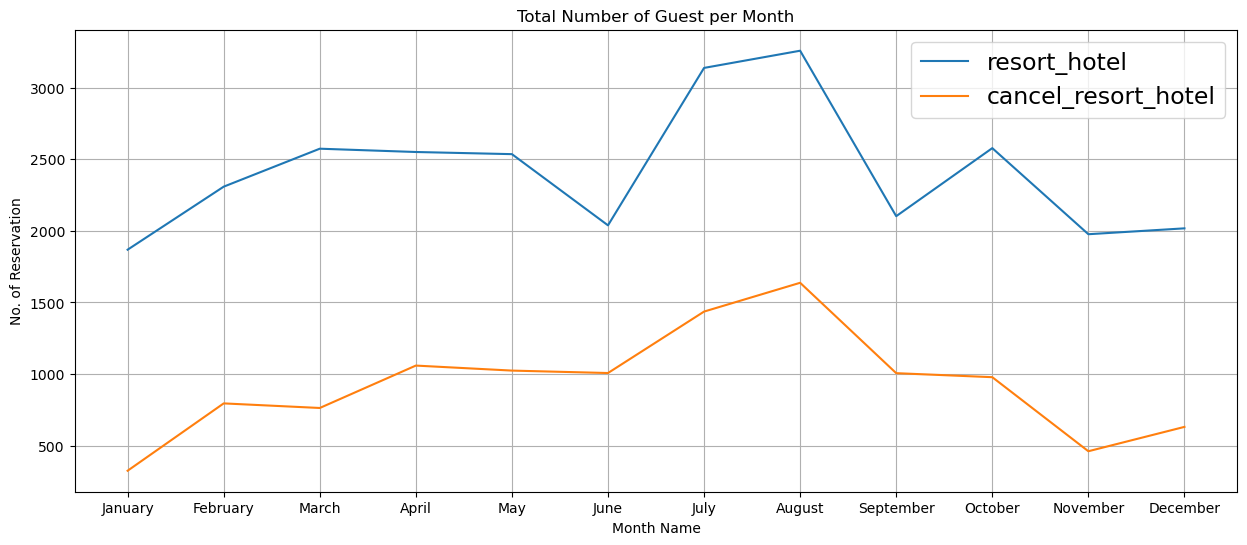

In [42]:
plt.figure(figsize = (15,6))
plt.plot(resort_hotel_booking['month_name'],resort_hotel_booking['total_booking'],label = 'resort_hotel')
plt.plot(cancel_resort_hotel_booking['month_name'],cancel_resort_hotel_booking['total_cancel_booking'],label = 'cancel_resort_hotel')
plt.title('Total Number of Guest per Month')
plt.legend(fontsize = 17)
plt.xlabel('Month Name')
plt.ylabel('No. of Reservation')
plt.grid()
plt.show()

# ADR

In [43]:
city_hotel = df.loc[df['hotel'] == 'City Hotel']

In [44]:
resort_hotel = df.loc[df['hotel'] == 'Resort Hotel']

In [45]:
city_hotel_adr = city_hotel.groupby(['arrival_date_month','month_number'],as_index = False)[['adr']].mean().rename(columns = {'adr':'Avg_ADR','arrival_date_month':'month_name'})

In [46]:
city_hotel_adr.sort_values('month_number',inplace = True)

In [47]:
city_hotel_adr

,month_name,month_number,Avg_ADR
4,January,1,82.628986
3,February,2,85.088278
7,March,3,92.643116
0,April,4,111.251838
8,May,5,121.638560
6,June,6,119.074341
5,July,7,110.734292
1,August,8,114.680455
11,September,9,110.004661
10,October,10,99.974498


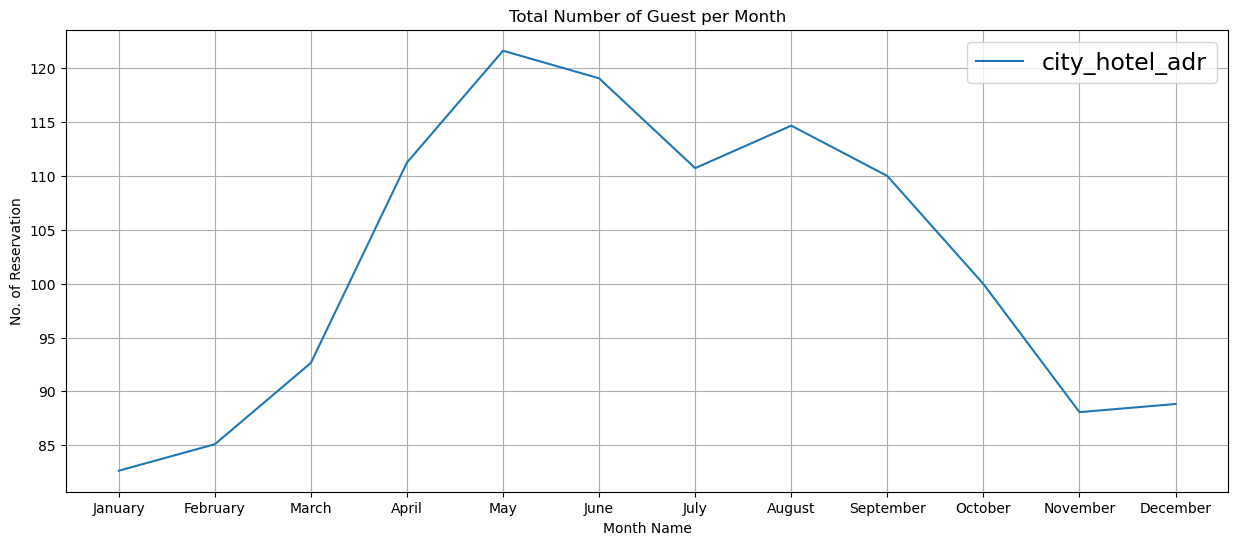

In [48]:
plt.figure(figsize = (15,6))
plt.plot(city_hotel_adr['month_name'],city_hotel_adr['Avg_ADR'],label = 'city_hotel_adr')
plt.title('Total Number of Guest per Month')
plt.legend(fontsize = 17)
plt.xlabel('Month Name')
plt.ylabel('No. of Reservation')
plt.grid()
plt.show()

In [49]:
cancel_city_hotel_booking

,month_name,month_number,total_cancel_booking
0,January,1,1482
1,February,2,1901
2,March,3,2386
3,April,4,3465
4,May,5,3653
5,June,6,3528
6,July,7,3306
7,August,8,3602
8,September,9,3110
9,October,10,3268


In [50]:
city_hotel_relation = pd.merge(cancel_city_hotel_booking,city_hotel_adr,how = 'inner',on = 'month_name')

In [51]:
city_hotel_relation.drop(['month_number_x','month_number_y'],axis = 1,inplace = True)

In [52]:
city_hotel_relation

,month_name,total_cancel_booking,Avg_ADR
0,January,1482,82.628986
1,February,1901,85.088278
2,March,2386,92.643116
3,April,3465,111.251838
4,May,3653,121.638560
5,June,3528,119.074341
6,July,3306,110.734292
7,August,3602,114.680455
8,September,3110,110.004661
9,October,3268,99.974498


In [53]:
city_hotel_relation[['total_cancel_booking','Avg_ADR']].corr()

,total_cancel_booking,Avg_ADR
total_cancel_booking,1.000000,0.950699
Avg_ADR,0.950699,1.000000


<Axes: >

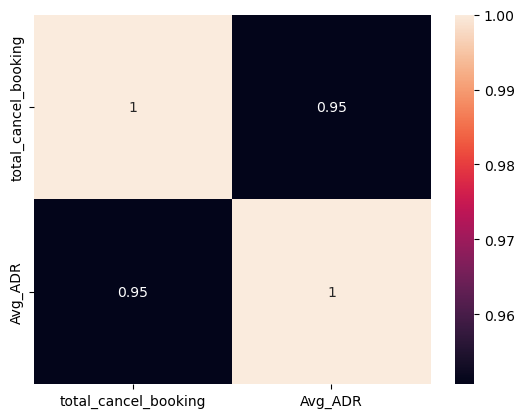

In [54]:
sns.heatmap(city_hotel_relation[['total_cancel_booking','Avg_ADR']].corr(),annot = True)

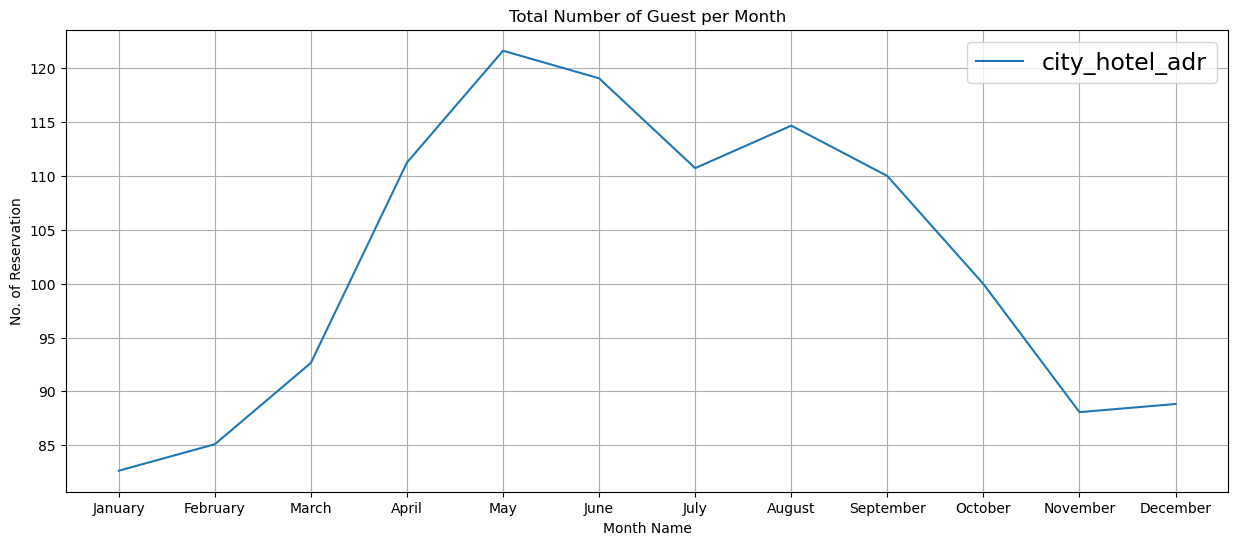

In [55]:
plt.figure(figsize = (15,6))
plt.plot(city_hotel_relation['month_name'],city_hotel_relation['Avg_ADR'],label = 'city_hotel_adr')

plt.title('Total Number of Guest per Month')
plt.legend(fontsize = 17)
plt.xlabel('Month Name')
plt.ylabel('No. of Reservation')
plt.grid()
plt.show()

# Market Segment

In [56]:
market_segment_group = pd.DataFrame(round((resort_hotel['market_segment'].value_counts(normalize=True)) * 100,2))
market_segment_group

,proportion
market_segment,
Online TA,44.26
Offline TA/TO,18.65
Direct,16.26
Groups,14.57
Corporate,5.76
Complementary,0.50


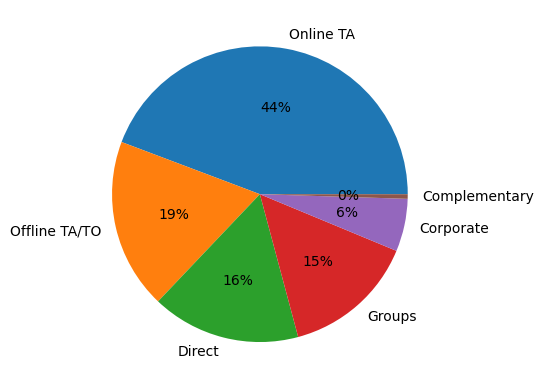

In [57]:
plt.pie(market_segment_group['proportion'],labels = market_segment_group.index,autopct = "%.0f%%")
plt.show()

# Repeated Guest Percentage

In [58]:
city_hotel_repeating_guest = round(city_hotel['is_repeated_guest'].value_counts(normalize=True),2)

In [59]:
city_hotel_repeating_guest

is_repeated_guest
0    0.97
1    0.03
Name: proportion, dtype: float64

In [60]:
print(f'New Guest :- {city_hotel_repeating_guest[0]} %')
print(f'Repeated Guest :- {city_hotel_repeating_guest[1]} %')

New Guest :- 0.97 %
Repeated Guest :- 0.03 %


# Most Reserved Room

In [61]:
city_room_type_percent = pd.DataFrame(round(city_hotel[['reserved_room_type']].value_counts(normalize=True)*100,2)).rename(columns = {0:'Share_of_rooms'})

In [62]:
city_room_type_percent.reset_index(inplace = True)

In [63]:
city_room_type_percent

,reserved_room_type,proportion
0,A,78.90
1,D,14.83
2,F,2.26
3,E,1.96
4,B,1.41
5,G,0.61
6,C,0.02
7,P,0.01


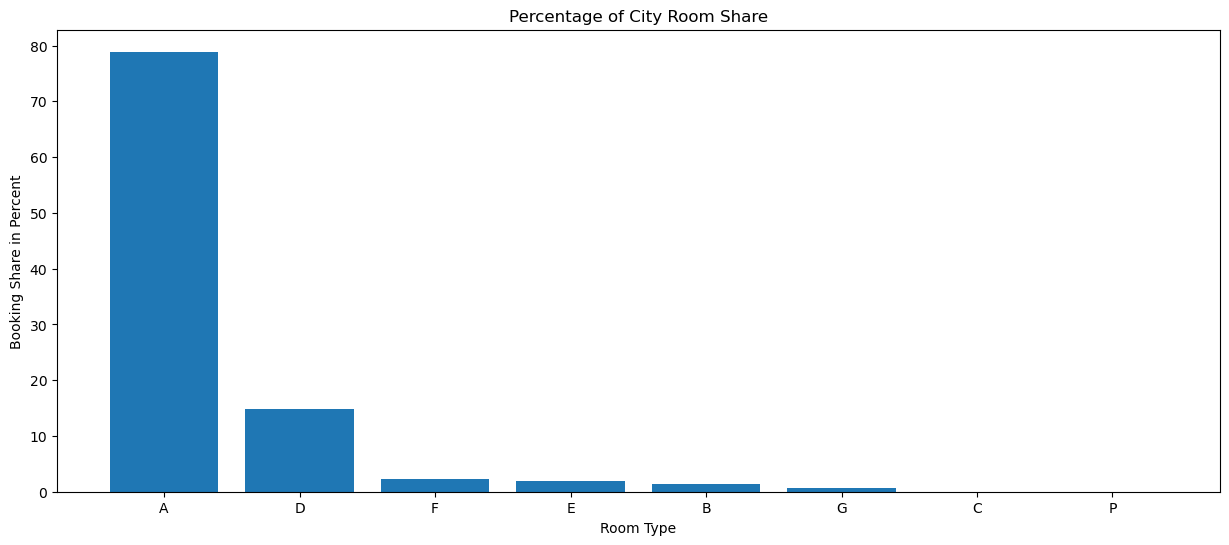

In [64]:
plt.figure(figsize = (15,6))
plt.bar(city_room_type_percent['reserved_room_type'],city_room_type_percent['proportion'])
plt.title('Percentage of City Room Share')
plt.xlabel('Room Type')
plt.ylabel('Booking Share in Percent')
plt.show()

In [65]:
resort_room_type_percent = pd.DataFrame(round(resort_hotel[['reserved_room_type']].value_counts(normalize=True)*100,2)).rename(columns = {0:'Share_of_rooms'})

In [66]:
resort_room_type_percent.reset_index(inplace = True)

In [67]:
resort_room_type_percent

,reserved_room_type,proportion
0,A,58.41
1,D,18.55
2,E,12.44
3,G,4.02
4,F,2.76
5,C,2.29
6,H,1.50
7,L,0.01
8,B,0.01
9,P,0.00


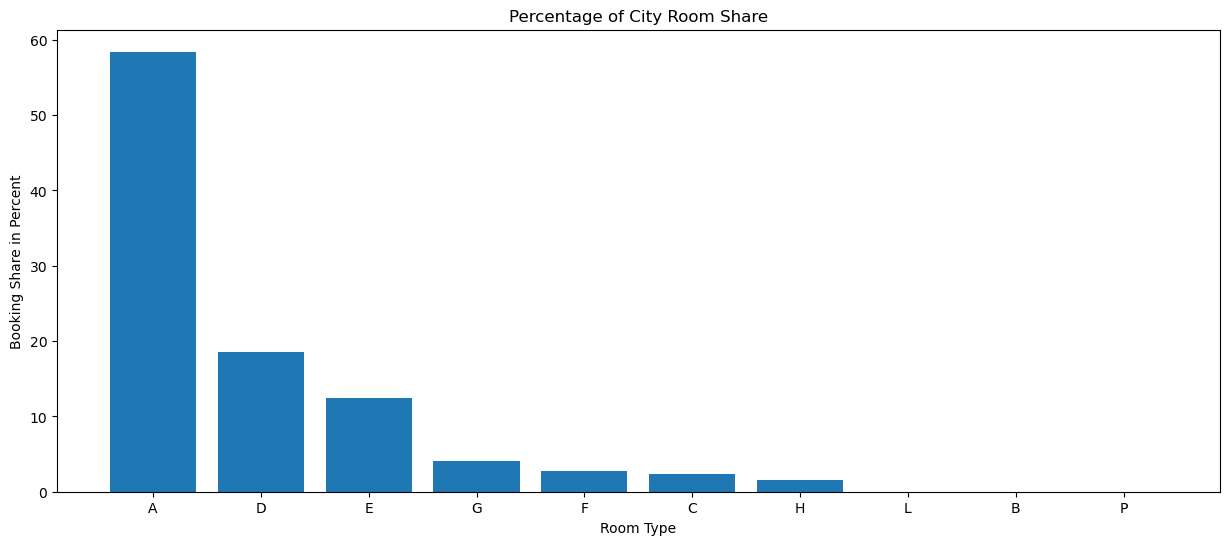

In [68]:
plt.figure(figsize = (15,6))
plt.bar(resort_room_type_percent['reserved_room_type'],resort_room_type_percent['proportion'])
plt.title('Percentage of City Room Share')
plt.xlabel('Room Type')
plt.ylabel('Booking Share in Percent')
plt.show()

# customer Type

In [69]:
df_reserved = df[df['is_canceled'] == 0]

In [70]:
customer_type = pd.DataFrame(round(df_reserved['customer_type'].value_counts(normalize=True)*100,2))

In [71]:
customer_type.reset_index(inplace = True)

In [72]:
customer_type.rename(columns = {'index' : 'customer_type','customer_type' : 'Percent'},inplace = True)

In [73]:
customer_type

,Percent,proportion
0,Transient,70.64
1,Transient-Party,24.92
2,Contract,3.74
3,Group,0.69


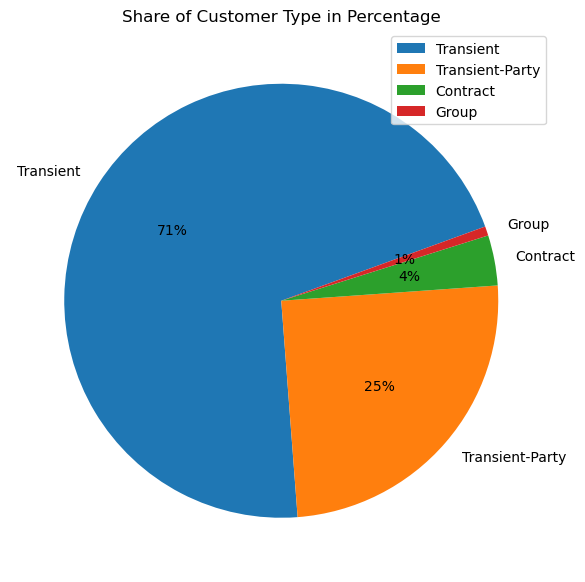

In [74]:
plt.figure(figsize = (7,10))
plt.pie(customer_type['proportion'],labels = customer_type['Percent'],autopct = '%1.f%%',startangle= 20)
plt.title('Share of Customer Type in Percentage')
plt.legend()
plt.show()

# Reservation Percentage

In [75]:
reservation_percent = pd.DataFrame(round(df['is_canceled'].value_counts(normalize = True)*100,2))

In [76]:
reservation_percent

,proportion
is_canceled,
0,62.96
1,37.04


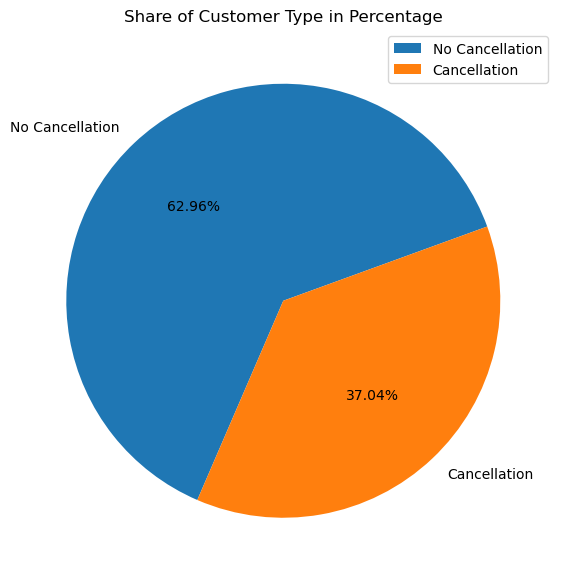

In [77]:
plt.figure(figsize = (7,10))
plt.pie(reservation_percent['proportion'],labels = ['No Cancellation','Cancellation'],autopct = '%1.2f%%',startangle= 20)
plt.title('Share of Customer Type in Percentage')
plt.legend()
plt.show()